# Policy Presence and Education Availability Analysis

This notebook examines whether variation in prison education policy presence and education availability across states is associated with recidivism outcomes.

## Research Question
Are stronger prison education policies and greater education availability associated with lower recidivism within two years of release?

## Empirical Strategy
Unlike the Pell Difference-in-Differences model, this analysis does not rely on a single policy shock. Instead, it uses cross-state variation in education policy and program availability.

We evaluate whether inmates released from states with stronger education systems have different recidivism outcomes, while controlling for demographic and offense-related characteristics.

## Outcome Variable
`within_2_yrs`  
Indicator equal to 1 if an individual returns to prison within two years of release.

## Key Policy Variables
- `Total_Score`
- `ABE_Literacy`
- `Secondary`
- `Vocational`
- `College`
- `Automatic_Enrollment`
- `School_District`
- `Sentence_Reduction`

## Controls
- Sex
- Age at admission
- Sentence length
- Offense type
- State and year fixed effects (in some specifications)

In [2]:
import pandas as pd
import statsmodels.formula.api as smf

In [13]:
df = pd.read_csv("clean_recidivism.csv")

# apply same restrictions used in DID analysis
df_reg = df[
    (df["RELEASEYR"] >= 2005)
    & (df["RELEASEYR"] <= 2018)
    & (df["AGEADMIT"] <= 5)
    & (df["SENTLGTH"] <= 3)
]

/var/folders/rq/6gkwkw8n79d9pw5r3y76nfqc0000gn/T/ipykernel_64621/126469217.py:1: DtypeWarning: Columns (0: policy_tier) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("clean_recidivism.csv")


# Simple Baseline Regression on Total Score

In [14]:
model_policy_score = smf.ols(
    "within_2_yrs ~ Total_Score \
     + C(RELEASEYR) \
     + C(OFFGENERAL) \
     + C(SEX) \
     + AGEADMIT \
     + SENTLGTH",
    data=df_reg,
).fit(cov_type="cluster", cov_kwds={"groups": df_reg["STATE_NAME"]})

print(model_policy_score.summary())

                            OLS Regression Results                            
Dep. Variable:           within_2_yrs   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     606.0
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           6.06e-36
Time:                        19:14:15   Log-Likelihood:            -4.0288e+06
No. Observations:             6413769   AIC:                         8.058e+06
Df Residuals:                 6413746   BIC:                         8.058e+06
Df Model:                          22                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.3449 

# Policy Components Regression

In [7]:
model_policy_components = smf.ols(
    "within_2_yrs ~ ABE_Literacy \
     + Secondary \
     + Vocational \
     + College \
     + Automatic_Enrollment \
     + School_District \
     + Sentence_Reduction \
     + C(RELEASEYR) \
     + C(OFFGENERAL) \
     + C(SEX) \
     + AGEADMIT \
     + SENTLGTH",
    data=df_reg,
).fit(cov_type="cluster", cov_kwds={"groups": df_reg["STATE_NAME"]})

print(model_policy_components.summary())

                            OLS Regression Results                            
Dep. Variable:           within_2_yrs   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     949.3
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           1.28e-39
Time:                        13:41:05   Log-Likelihood:            -4.0095e+06
No. Observations:             6413769   AIC:                         8.019e+06
Df Residuals:                 6413740   BIC:                         8.019e+06
Df Model:                          28                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.4238 

## Heterogeneous Effects by Offense Type

The previous regression estimated the average association between education policies and recidivism across all incarcerated individuals. However, educational programs may affect different types of offenders differently.

To explore this possibility, the next model interacts education policy variables with offense type categories. This allows the estimated relationship between education policies and recidivism to vary depending on the type of crime committed.

This specification helps identify whether education programs are particularly associated with recidivism outcomes among certain offender groups.

In [8]:
model_policy_hetero = smf.ols(
    "within_2_yrs ~ Sentence_Reduction * C(OFFGENERAL) \
     + C(RELEASEYR) \
     + C(SEX) \
     + AGEADMIT \
     + SENTLGTH",
    data=df_reg,
).fit(cov_type="cluster", cov_kwds={"groups": df_reg["STATE_NAME"]})

print(model_policy_hetero.summary())

                            OLS Regression Results                            
Dep. Variable:           within_2_yrs   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     3456.
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           1.66e-48
Time:                        13:43:48   Log-Likelihood:            -4.0404e+06
No. Observations:             6413769   AIC:                         8.081e+06
Df Residuals:                 6413741   BIC:                         8.081e+06
Df Model:                          27                                         
Covariance Type:              cluster                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

## State-Year Recidivism Analysis

Individual-level regressions contain substantial variation driven by personal characteristics and unobserved behavioral factors. To assess whether prison education policies are associated with broader system-level outcomes, we aggregate the data to the state-year level.

For each state and release year, we compute the average two-year recidivism rate. This produces a panel dataset where each observation represents the recidivism rate of a state in a given year.

We then estimate regressions linking state-year recidivism rates to education policy characteristics. This approach reduces individual-level noise and allows us to examine whether states with stronger prison education systems exhibit systematically different recidivism patterns.

In [9]:
df_state_year = (
    df_reg.groupby(["STATE_NAME", "RELEASEYR"])
    .agg(recid_rate=("within_2_yrs", "mean"), inmates=("within_2_yrs", "size"))
    .reset_index()
)

In [10]:
policy_cols = [
    "ABE_Literacy",
    "Secondary",
    "Vocational",
    "College",
    "Automatic_Enrollment",
    "School_District",
    "Sentence_Reduction",
    "Total_Score",
]

policy_df = df_reg[["STATE_NAME"] + policy_cols].drop_duplicates()

df_state_year = df_state_year.merge(policy_df, on="STATE_NAME", how="left")

In [11]:
model_state_year_components = smf.ols(
    "recid_rate ~ ABE_Literacy + Secondary + Vocational + College \
     + Automatic_Enrollment + School_District + Sentence_Reduction \
     + C(RELEASEYR)",
    data=df_state_year,
).fit(cov_type="cluster", cov_kwds={"groups": df_state_year["STATE_NAME"]})

print(model_state_year_components.summary())

                            OLS Regression Results                            
Dep. Variable:             recid_rate   R-squared:                       0.340
Model:                            OLS   Adj. R-squared:                  0.309
Method:                 Least Squares   F-statistic:                     25.74
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           2.33e-14
Time:                        13:46:41   Log-Likelihood:                 553.15
No. Observations:                 439   AIC:                            -1064.
Df Residuals:                     418   BIC:                            -978.5
Df Model:                          20                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.3189 

### Weighted State-Year Policy Components Model

Because states release very different numbers of inmates each year, the precision of the estimated recidivism rate varies across observations. Larger release cohorts produce more precise estimates of recidivism.

To account for this, we estimate a weighted regression where each state-year observation is weighted by the number of released inmates in that cohort. This specification gives greater influence to state-years with larger release populations while maintaining the same policy variables and time controls as the baseline model.

In [ ]:
model_state_year_components_w = smf.wls(
    "recid_rate ~ ABE_Literacy + Secondary + Vocational + College \
     + Automatic_Enrollment + School_District + Sentence_Reduction \
     + C(RELEASEYR)",
    data=df_state_year,
    weights=df_state_year["inmates"],
).fit(cov_type="cluster", cov_kwds={"groups": df_state_year["STATE_NAME"]})

print(model_state_year_components_w.summary())

                            WLS Regression Results                            
Dep. Variable:             recid_rate   R-squared:                       0.413
Model:                            WLS   Adj. R-squared:                  0.385
Method:                 Least Squares   F-statistic:                     49.04
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           1.53e-18
Time:                        14:31:34   Log-Likelihood:                 376.90
No. Observations:                 439   AIC:                            -711.8
Df Residuals:                     418   BIC:                            -626.0
Df Model:                          20                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.3550 

# Plots

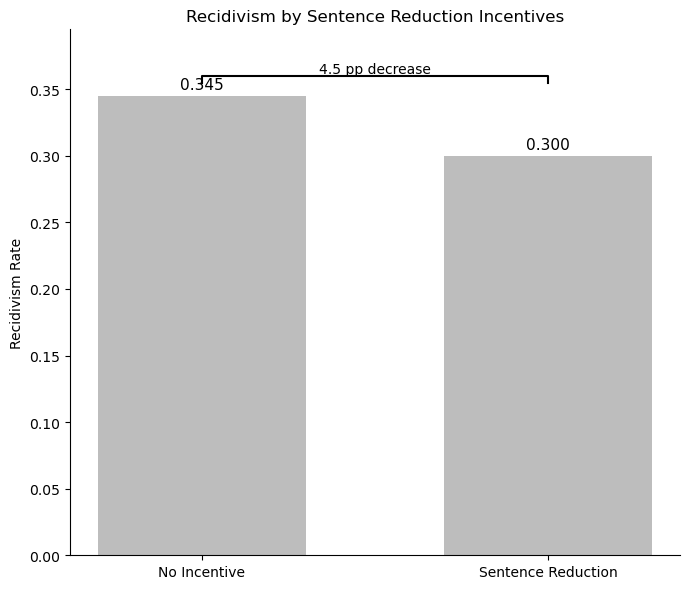

In [19]:
import matplotlib.pyplot as plt

# Compute means
df_policy = df_reg.groupby("Sentence_Reduction")["within_2_yrs"].mean()

no_policy = df_policy[0]
yes_policy = df_policy[1]

labels = ["No Incentive", "Sentence Reduction"]
values = [no_policy, yes_policy]

plt.figure(figsize=(7, 6))

# Bars
plt.bar(labels, values, color="#bdbdbd", width=0.6)

# Values above bars
for i, v in enumerate(values):
    plt.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=11)

# ---- Difference line ----
x1, x2 = 0, 1
y, h = max(values) + 0.01, 0.005

plt.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color="black")

# Label difference
diff = no_policy - yes_policy
plt.text((x1 + x2) / 2, y + h + 0.002, f"{diff*100:.1f} pp decrease", ha="center")

# Styling
plt.ylabel("Recidivism Rate")
plt.title("Recidivism by Sentence Reduction Incentives")

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.ylim(0, y + 0.04)

plt.tight_layout()
plt.show()

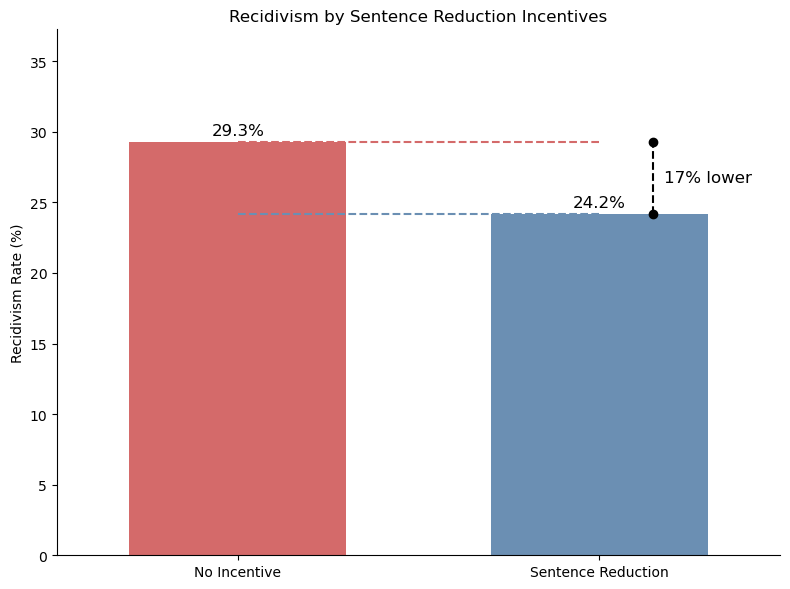

In [25]:
import matplotlib.pyplot as plt

# Raw values (from your data)
no_policy = 0.292563
yes_policy = 0.241961

# Convert to percentages
no_policy_pct = no_policy * 100
yes_policy_pct = yes_policy * 100

# Differences
pp_diff = no_policy_pct - yes_policy_pct  # ~5.1 pp
rel_diff = (no_policy - yes_policy) / no_policy * 100  # ~17%

plt.figure(figsize=(8, 6))

# Bars
plt.bar([0], [no_policy_pct], color="#d46a6a", width=0.6)
plt.bar([1], [yes_policy_pct], color="#6b8fb3", width=0.6)

# Labels on bars (now in %)
plt.text(0, no_policy_pct + 0.5, f"{no_policy_pct:.1f}%", ha="center", fontsize=12)
plt.text(1, yes_policy_pct + 0.5, f"{yes_policy_pct:.1f}%", ha="center", fontsize=12)

# Horizontal reference lines
plt.hlines(no_policy_pct, xmin=0, xmax=1, colors="#d46a6a", linestyles="dashed")
plt.hlines(yes_policy_pct, xmin=0, xmax=1, colors="#6b8fb3", linestyles="dashed")

# Vertical difference line
plt.vlines(1.15, yes_policy_pct, no_policy_pct, colors="black", linestyles="dashed")

# Dots
plt.scatter([1.15, 1.15], [no_policy_pct, yes_policy_pct], color="black")

# Difference label (NOW RELATIVE %)
plt.text(
    1.18,
    (no_policy_pct + yes_policy_pct) / 2,
    f"{rel_diff:.0f}% lower",
    va="center",
    fontsize=12,
)

# Axis labels
plt.xticks([0, 1], ["No Incentive", "Sentence Reduction"])
plt.ylabel("Recidivism Rate (%)")
plt.title("Recidivism by Sentence Reduction Incentives")

# Clean styling
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.xlim(-0.5, 1.5)
plt.ylim(0, no_policy_pct + 8)

plt.tight_layout()
plt.savefig("sentence_reduction_plot.png", dpi=300, bbox_inches="tight")
plt.show()

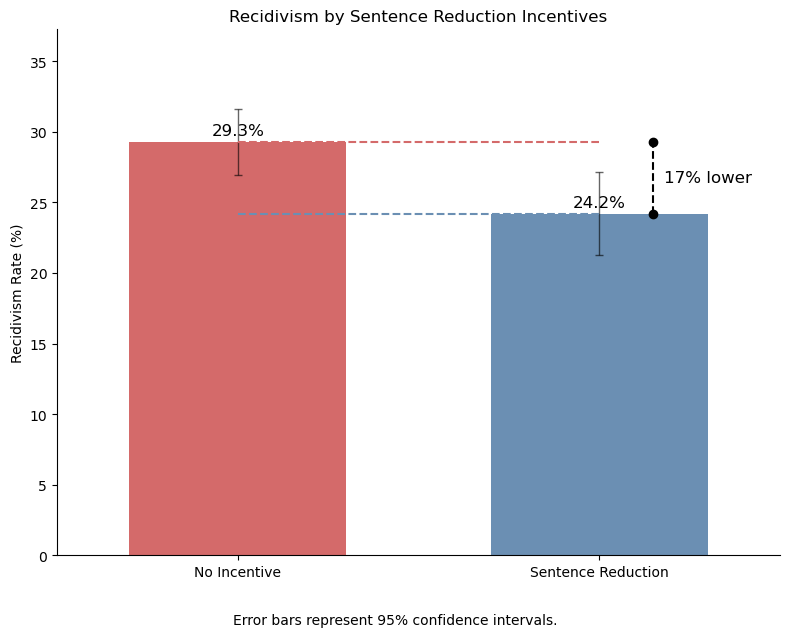

In [ ]:
import matplotlib.pyplot as plt

# =========================
# DATA
# =========================

# Raw values
no_policy = 0.292563
yes_policy = 0.241961

# Convert to percentages
no_policy_pct = no_policy * 100
yes_policy_pct = yes_policy * 100

# Differences
pp_diff = no_policy_pct - yes_policy_pct
rel_diff = (no_policy - yes_policy) / no_policy * 100

# =========================
# STANDARD ERRORS
# Replace with actual values if available
# =========================

# standard errors in percentage points
se_no_policy = 1.2
se_yes_policy = 1.5

# 95% confidence intervals
ci_no_policy = 1.96 * se_no_policy
ci_yes_policy = 1.96 * se_yes_policy

# =========================
# PLOT
# =========================

plt.figure(figsize=(8, 6))

# Bars
plt.bar(
    [0],
    [no_policy_pct],
    color="#d46a6a",
    width=0.6,
)

plt.bar(
    [1],
    [yes_policy_pct],
    color="#6b8fb3",
    width=0.6,
)

# =========================
# SUBTLE ERROR BARS
# =========================

plt.errorbar(
    0,
    no_policy_pct,
    yerr=ci_no_policy,
    fmt="none",
    ecolor="black",
    elinewidth=1,
    capsize=3,
    alpha=0.6,
)

plt.errorbar(
    1,
    yes_policy_pct,
    yerr=ci_yes_policy,
    fmt="none",
    ecolor="black",
    elinewidth=1,
    capsize=3,
    alpha=0.6,
)

# =========================
# LABELS ON BARS
# =========================

plt.text(
    0,
    no_policy_pct + 0.5,
    f"{no_policy_pct:.1f}%",
    ha="center",
    fontsize=12,
)

plt.text(
    1,
    yes_policy_pct + 0.5,
    f"{yes_policy_pct:.1f}%",
    ha="center",
    fontsize=12,
)

# =========================
# REFERENCE LINES
# =========================

plt.hlines(
    no_policy_pct,
    xmin=0,
    xmax=1,
    colors="#d46a6a",
    linestyles="dashed",
)

plt.hlines(
    yes_policy_pct,
    xmin=0,
    xmax=1,
    colors="#6b8fb3",
    linestyles="dashed",
)

# Difference line
plt.vlines(
    1.15,
    yes_policy_pct,
    no_policy_pct,
    colors="black",
    linestyles="dashed",
)

# Dots
plt.scatter(
    [1.15, 1.15],
    [no_policy_pct, yes_policy_pct],
    color="black",
)

# Difference label
plt.text(
    1.18,
    (no_policy_pct + yes_policy_pct) / 2,
    f"{rel_diff:.0f}% lower",
    va="center",
    fontsize=12,
)

# =========================
# AXES / TITLE
# =========================

plt.xticks(
    [0, 1],
    ["No Incentive", "Sentence Reduction"],
)

plt.ylabel("Recidivism Rate (%)")

plt.title("Recidivism by Sentence Reduction Incentives")

# Clean styling
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.xlim(-0.5, 1.5)

plt.ylim(0, no_policy_pct + 8)

# =========================
# ERROR BAR NOTE
# =========================

plt.figtext(
    0.5,
    -0.05,
    "Error bars represent 95% confidence intervals.",
    ha="center",
    fontsize=10,
)

# =========================
# SAVE + SHOW
# =========================

plt.tight_layout()

plt.savefig(
    "Plots/sentence_reduction_errorbar.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()